<a href="https://colab.research.google.com/github/specM7/DSGP_Group_33_Brain_Tumor_Predictor/blob/NoTumor-%26-Chatbot-Ahshaan-2506751/NoTumor_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import os

In [3]:
# Dataset path (binary structure)
data_dir = "/content/drive/MyDrive/NoTumor_Detection/Binary_Dataset"

train_dir = os.path.join(data_dir, "Training")
test_dir = os.path.join(data_dir, "Testing")

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# Testing data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5600 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [5]:
# Simple CNN model for binary classification

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Binary output
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 1113s 6s/step - accuracy: 0.8538 - loss: 0.3559 - val_accuracy: 0.8656 - val_loss: 0.4224
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 771s 4s/step - accuracy: 0.9551 - loss: 0.1356 - val_accuracy: 0.8994 - val_loss: 0.2309
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 785s 4s/step - accuracy: 0.9578 - loss: 0.1170 - val_accuracy: 0.8975 - val_loss: 0.3242
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 775s 4s/step - accuracy: 0.9687 - loss: 0.0953 - val_accuracy: 0.8900 - val_loss: 0.3638
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 771s 4s/step - accuracy: 0.9741 - loss: 0.0813 - val_accuracy: 0.9225 - val_loss: 0.1753
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 774s 4s/step - accuracy: 0.9746 - loss: 0.0772 - val_accuracy: 0.8981 - val_loss: 0.3486
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 770s 4s/step - accuracy: 0.9749 - loss: 0.0707 - val_accuracy: 0.8881 - val_loss: 0.3724
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 819s 4s/step - accuracy: 0.9700 - loss: 0.0770 - val_acc

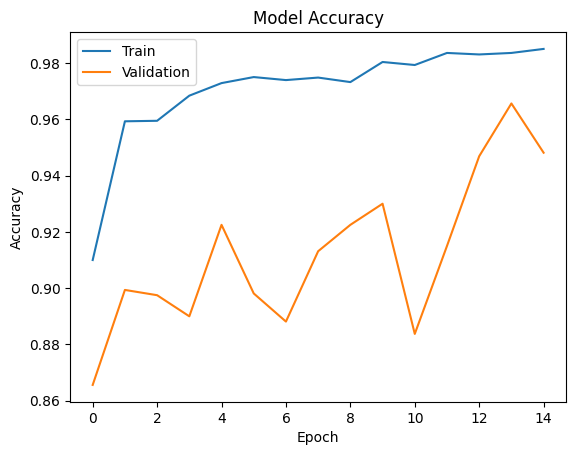

In [7]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

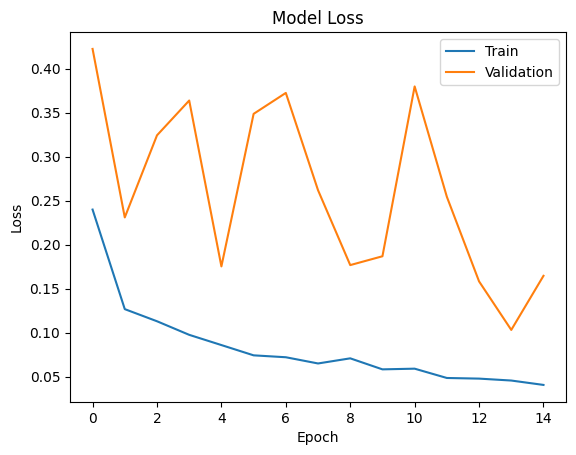

In [8]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step
Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       400
           1       1.00      0.93      0.96      1200

    accuracy                           0.95      1600
   macro avg       0.91      0.97      0.94      1600
weighted avg       0.96      0.95      0.95      1600



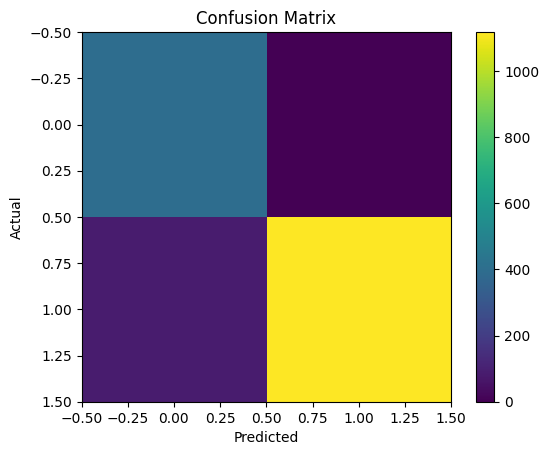

In [9]:
# Predictions
predictions = model.predict(test_generator)
pred_classes = (predictions > 0.5).astype(int)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, pred_classes)

print("Classification Report:\n")
print(classification_report(true_classes, pred_classes))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

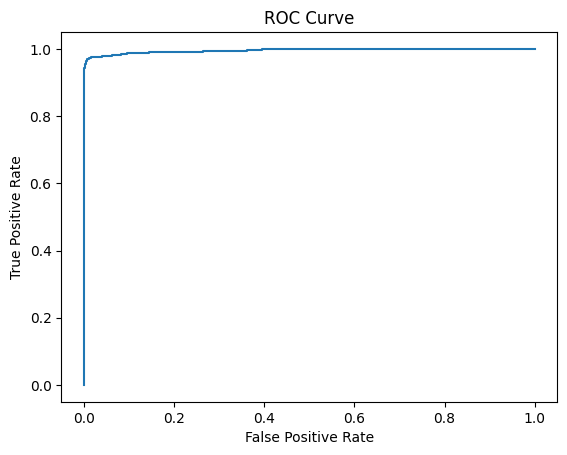

AUC Score: 0.9949166666666667


In [14]:
fpr, tpr, thresholds = roc_curve(true_classes, predictions)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc)

In [15]:
model_save_path = "/content/drive/MyDrive/NoTumor_Detection/NoTumor_CNN_Model.h5"
model.save(model_save_path)

print("Model saved successfully.")

Model saved successfully.


In [17]:
# Import only required libraries
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import drive, files

# Mount Drive
drive.mount('/content/drive')

# Load saved model
model_path = "/content/drive/MyDrive/NoTumor_Detection/NoTumor_CNN_Model.h5"
model = tf.keras.models.load_model(model_path)

print("Model loaded successfully")

# Upload MRI image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)[0][0]

print("Raw Prediction Value:", prediction)

if prediction >= 0.5:
    print("Final Result: Tumor Detected")
else:
    print("Final Result: No Tumor Detected")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model loaded successfully


Saving Te-no_3.jpg to Te-no_3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Raw Prediction Value: 8.709834e-09
Final Result: No Tumor Detected
